<a href="https://colab.research.google.com/github/joyumoh/Titanic-Prediction-Model/blob/main/Titanic_Prediction_and_ML%20Concepts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)

# Load the cleaned dataset saved at end of Week 2
df = pd.read_csv("/content/cleaned_titanic.csv")
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,TicketGroup,Sex_male,...,Title_Mrs,Title_Rare,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_U
0,0,3,22.0,1,0,7.2500,2,0,1,True,...,False,False,False,False,False,False,False,False,False,True
1,1,1,38.0,1,0,71.2833,2,0,1,False,...,True,False,False,True,False,False,False,False,False,False
2,1,3,26.0,0,0,7.9250,1,1,1,False,...,False,False,False,False,False,False,False,False,False,True
3,1,1,35.0,1,0,53.1000,2,0,2,False,...,True,False,False,True,False,False,False,False,False,False
4,0,3,35.0,0,0,8.0500,1,1,1,True,...,False,False,False,False,False,False,False,False,False,True


## Supervised vs Unsupervised Learning

**Supervised Learning:**
The model learns from labelled data — input features (X) and a known output (y).
- Examples: Logistic Regression, Decision Trees, Random Forest
- Real-world use: Email spam detection, disease diagnosis, Titanic survival prediction

**Unsupervised Learning:**
The model finds hidden patterns in data with NO labels.
- Examples: K-Means Clustering, PCA, DBSCAN
- Real-world use: Customer segmentation, anomaly detection, topic modelling

The Titanic problem is SUPERVISED — I'm predicting 'Survived' (0 or 1),
which is a known label in the dataset.

In [2]:
# Define features (X) and target (y)
X = df.drop(columns=['Survived'])
y = df['Survived']

print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Features shape: (891, 23)
Target distribution:
 Survived
0    549
1    342
Name: count, dtype: int64


In [3]:
## Train/Test Split

# Why? — We train the model on one portion and test on unseen data
# to simulate real-world performance before deployment.
# Common split: 80% train, 20% test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size: ", X_test.shape)

Training set size: (712, 23)
Testing set size:  (179, 23)


## Why Split Data?

- Training data: The model learns patterns from this portion.
- Testing data: Evaluates how well the model generalises to NEW, unseen data.
- Without a test split, you cannot know if the model truly learned
  or just memorised the training data (overfitting).
- The random_state=42 ensures reproducibility — same split every run.

In [7]:
# Model 1: Logistic Regression (simpler — less likely to overfit)
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)
print("Logistic Regression model trained.")

# Model 2: Decision Tree (prone to overfitting if unconstrained)
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
print("Decision Tree model trained.")

Logistic Regression model trained.
Decision Tree model trained.


In [6]:
## Overfitting vs Underfitting

# Compare train vs test accuracy for both models

print("=== Logistic Regression ===")
print("Train Accuracy:", round(accuracy_score(y_train, log_model.predict(X_train)), 4))
print("Test Accuracy: ", round(accuracy_score(y_test,  log_model.predict(X_test)), 4))

print("\n=== Decision Tree (Unconstrained) ===")
print("Train Accuracy:", round(accuracy_score(y_train, dt_model.predict(X_train)), 4))
print("Test Accuracy: ", round(accuracy_score(y_test,  dt_model.predict(X_test)), 4))

=== Logistic Regression ===
Train Accuracy: 0.8357
Test Accuracy:  0.8156

=== Decision Tree (Unconstrained) ===
Train Accuracy: 0.9846
Test Accuracy:  0.7765


## Confusion Matrix for Unconstrained Decision Tree

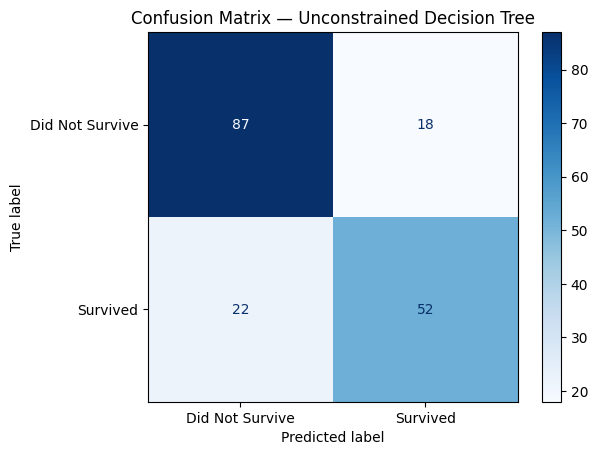

In [13]:
# Predict on the test set using the unconstrained Decision Tree
y_pred_dt_unconstrained = dt_model.predict(X_test)

# Calculate and display the confusion matrix
cm_dt_unconstrained = confusion_matrix(y_test, y_pred_dt_unconstrained)
disp_dt_unconstrained = ConfusionMatrixDisplay(confusion_matrix=cm_dt_unconstrained, display_labels=['Did Not Survive', 'Survived'])
disp_dt_unconstrained.plot(cmap='Blues')
plt.title("Confusion Matrix — Unconstrained Decision Tree")
plt.show()

## Overfitting vs Underfitting

**Overfitting:**
- Model learns training data TOO well, including noise.
- High train accuracy, low test accuracy.
- Example: Unconstrained Decision Tree above.
- Fix: Pruning (max_depth), cross-validation, more data, regularisation.

**Underfitting:**
- Model is too simple to capture patterns.
- Low accuracy on BOTH train and test.
- Example: A model that predicts everyone dies regardless of features.
- Fix: Use a more complex algorithm, add more features, reduce regularisation.

**Goal: A model with close train and test accuracy = good generalisation.**

In [9]:
# Fix overfitting by constraining tree depth
dt_pruned = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_pruned.fit(X_train, y_train)

print("=== Pruned Decision Tree (max_depth=4) ===")
print("Train Accuracy:", round(accuracy_score(y_train, dt_pruned.predict(X_train)), 4))
print("Test Accuracy: ", round(accuracy_score(y_test,  dt_pruned.predict(X_test)), 4))

=== Pruned Decision Tree (max_depth=4) ===
Train Accuracy: 0.8399
Test Accuracy:  0.8268


Accuracy: 0.8268


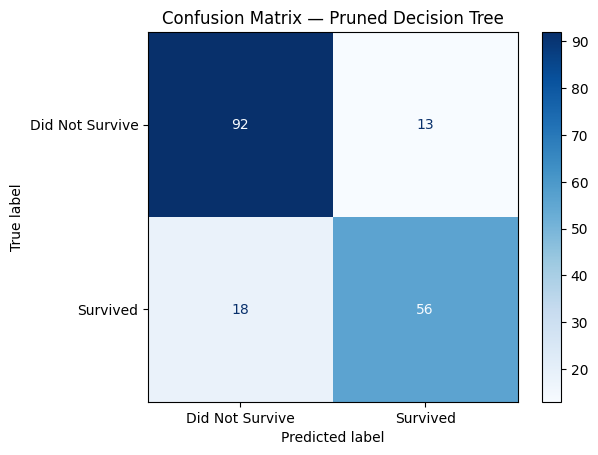


Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.84      0.88      0.86       105
       Survived       0.81      0.76      0.78        74

       accuracy                           0.83       179
      macro avg       0.82      0.82      0.82       179
   weighted avg       0.83      0.83      0.83       179



In [11]:
## Model Evaluation

# Use the pruned Decision Tree as your primary evaluated model
y_pred = dt_pruned.predict(X_test)

# 1. Accuracy
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did Not Survive', 'Survived'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Pruned Decision Tree")
plt.show()

# 3. Classification Report (Precision, Recall, F1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Did Not Survive', 'Survived']))

## Evaluation Metrics Explained

**Accuracy:** Percentage of all predictions that were correct.
  - Formula: (TP + TN) / Total

**Confusion Matrix:** A table showing True Positives, True Negatives,
  False Positives, and False Negatives.

**Precision:** Of all predicted survivors, how many actually survived?
  - High precision = fewer false alarms.

**Recall:** Of all actual survivors, how many did the model catch?
  - High recall = fewer missed survivors.

**F1 Score:** Harmonic mean of Precision and Recall.
  - Useful when classes are imbalanced (as in our dataset).

A model performs well when accuracy, precision, and recall are all
reasonably high and consistent between train and test sets.

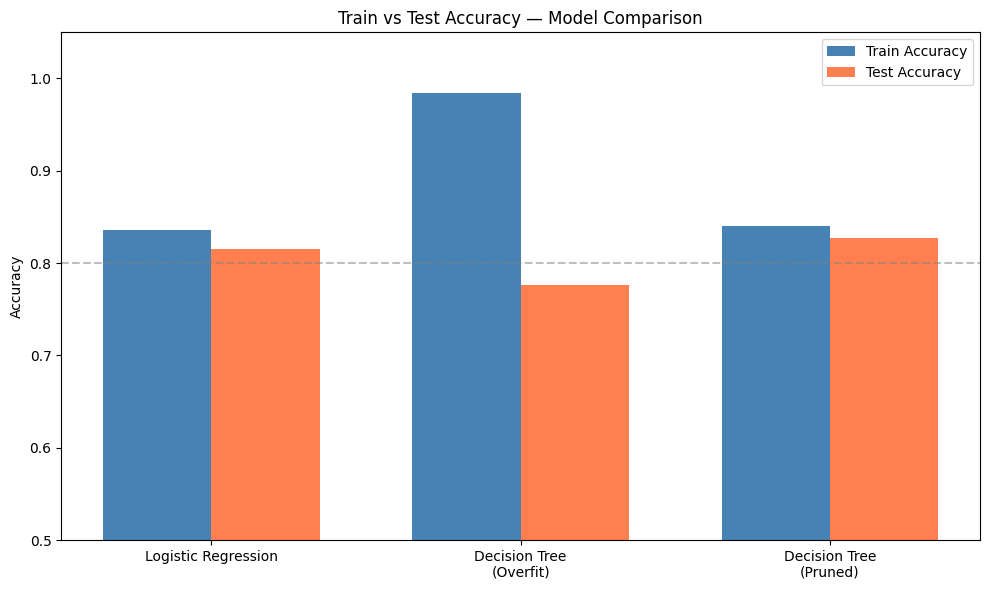

In [12]:
# Bar chart comparing model accuracies
models = ['Logistic Regression', 'Decision Tree\n(Overfit)', 'Decision Tree\n(Pruned)']
train_scores = [
    accuracy_score(y_train, log_model.predict(X_train)),
    accuracy_score(y_train, dt_model.predict(X_train)),
    accuracy_score(y_train, dt_pruned.predict(X_train))
]
test_scores = [
    accuracy_score(y_test, log_model.predict(X_test)),
    accuracy_score(y_test, dt_model.predict(X_test)),
    accuracy_score(y_test, dt_pruned.predict(X_test))
]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, train_scores, width, label='Train Accuracy', color='steelblue')
ax.bar(x + width/2, test_scores,  width, label='Test Accuracy',  color='coral')

ax.set_ylabel('Accuracy')
ax.set_title('Train vs Test Accuracy — Model Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.5, 1.05)
ax.legend()
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='0.8 benchmark')
plt.tight_layout()
plt.show()